# Del 0: Innledning
# Romlig analyse av tilfluktsrom og befolkning i Agder

## 0.1 Bakgrunn

Som en del av temaet *Totalforsvarets år* undersøker denne notebooken hvordan tilfluktsrom er geografisk distribuert i forhold til befolkningen i Agder.

Tilgang til tilfluktsrom er en sentral del av sivil beredskap. Den romlige fordelingen av slike anlegg kan ha stor betydning for hvor godt befolkningen er beskyttet i en krisesituasjon.

Ved å kombinere data om tilfluktsrom med befolkningsdata og geografiske analyser, er det mulig å identifisere områder med god eller svak dekning. Dette gir et mer nyansert bilde av beredskapssituasjonen enn å kun visualisere hvor tilfluktsrommene ligger.

---

## 0.2 Problemstilling

Analysen forsøker å besvare følgende spørsmål:

1. Hvor ligger tilfluktsrommene i Agder?
2. Hvordan er de geografisk fordelt i forhold til hvor befolkningen bor?
3. Finnes det områder med høy befolkningstetthet som har svak tilgang til tilfluktsrom?
4. Hvordan kan romlige analysemetoder brukes for å avdekke slike mønstre?

---

## 0.3 Planlagt analyse

Notebooken dokumenterer en fullstendig romlig analyseprosess som inkluderer:

- innlasting av flere geografiske datasett
- filtrering av data til Agder
- visualisering av tilfluktsrom og befolkningsdata
- bufferanalyse rundt tilfluktsrom
- overlay-analyse for å identifisere dekkede og ikke-dekkede områder
- romlig aggregering av befolkning innenfor og utenfor dekning
- rasteranalyse av terreng (helning og egnethet)

Målet er å gå fra en enkel visualisering av data til en mer analytisk vurdering av geografisk dekning og beredskap.

---

## 0.4 Datasett

Analysen tar utgangspunkt i følgende datasett:

- **Tilfluktsrom**: punktdata fra prosjektets PostGIS-database (`public.shelters`)
- **Fylkesgrenser**: polygondata fra prosjektets PostGIS-database (`public.fylker`)
- **Befolkningsrutenett 250 m**: data fra GeoNorge/SSB, importert til PostGIS (`public.befolkning_rutenett_250m_2025`)
- **Terrengdata (DEM)**: rasterdata brukt til helningsanalyse, polygonisering og hillshade

Datasettet for tilfluktsrom dekker hele Norge og filtreres til Agder ved hjelp av romlige operasjoner.
Befolkningsdata brukes for å analysere hvor mennesker faktisk bor, og gjør det mulig å vurdere dekning i et samfunnsperspektiv.

---

## 0.5 Verktøy

Følgende Python-biblioteker benyttes i analysen:

- `pandas`
- `geopandas`
- `matplotlib`
- `rasterio`
- `shapely`
- `sqlalchemy`
- `duckdb`

Disse verktøyene brukes til å håndtere data, utføre romlige analyser og visualisere resultatene i notebooken.

# Del 1. Oppsett og biblioteker

I denne delen settes det tekniske grunnlaget for analysen.

Nødvendige Python-biblioteker importeres, og det gjøres enkle innstillinger for å sikre at data og visualiseringer presenteres på en ryddig og lesbar måte i notebooken.

## 1.1 Import av biblioteker

Her importeres bibliotekene som brukes i analysen.

Disse dekker:
- håndtering av tabulære data
- romlige analyser
- visualisering
- rasteranalyse
- databasetilkobling

Ved å samle alle imports på ett sted blir notebooken mer oversiktlig og enklere å vedlikeholde.

In [10]:
import os
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

import sqlalchemy
from sqlalchemy import text

import rasterio
from rasterio.plot import show
from rasterio.features import shapes

from shapely.geometry import shape

from dotenv import load_dotenv

import duckdb

## 1.2 Valg av arbeidsmiljø og visualiseringsinnstillinger

For å gjøre utskrifter og figurer lettere å lese, settes noen enkle visningsinnstillinger.

Dette påvirker ikke selve analysen, men gjør det enklere å tolke resultater og jobbe effektivt i notebooken.

In [12]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

# Del 2. Innlasting og kontroll av data

I denne delen lastes de sentrale datasettene som brukes i analysen inn i notebooken.

Målet er å etablere et tydelig og kontrollert datagrunnlag før videre romlige analyser gjennomføres.
Siden flere av datasettene er lagret i prosjektets PostgreSQL/PostGIS-database, brukes databasen som primær datakilde.

Følgende datasett leses inn:

- fylkesgrenser fra `public.fylker`
- tilfluktsrom fra `public.shelters`
- befolkningsrutenett fra `public.befolkning_rutenett_250m_2025`

Alle datasettene kontrolleres etter innlasting for å sikre at struktur, geometri og koordinatsystem er korrekt før videre analyse.

## 2.1 Laste miljøvariabler og opprette databaseforbindelse

I denne delen lastes miljøvariabler fra prosjektets `.env`-fil, og det opprettes en forbindelse til PostgreSQL/PostGIS-databasen.
Dette gjør det mulig å hente geografiske data direkte fra databasen og sikre en konsistent arbeidsflyt i analysen.
For å bekrefte at tilkoblingen fungerer, kjøres en enkel testspørring mot databasen.

In [13]:
load_dotenv(Path("..") / ".env")

database_url = os.getenv("DATABASE_URL")

print("DATABASE_URL funnet:", database_url is not None)

DATABASE_URL funnet: True


## 2.2 Kontrollere at databaseforbindelsen fungerer

Etter at miljøvariablene er lastet inn, opprettes en forbindelse til databasen. Deretter kjøres en enkel testspørring for å kontrollere at forbindelsen fungerer som forventet. Dette er viktig før videre innlasting av geografiske data fra databasen.

In [14]:
engine = sqlalchemy.create_engine(database_url)

with engine.connect() as conn:
    result = conn.execute(text("SELECT current_database(), current_user;"))
    for row in result:
        print("Tilkobling vellykket")
        print("Database:", row[0])
        print("Bruker:", row[1])

Tilkobling vellykket
Database: postgres
Bruker: postgres


## 2.3 Lese inn fylkesgrense for Agder

For å avgrense analysen til riktig studieområde leses fylkesgrensen for Agder inn fra tabellen `public.fylker`.

Denne geometrien brukes videre som geografisk avgrensning for resten av analysen. Ved å hente fylkespolygonet direkte fra databasen sikres det at analyseområdet er konsistent med de øvrige dataene i prosjektet.

In [16]:
sql_agder = """
SELECT
    id,
    navn,
    geomfylke
FROM public.fylker
WHERE navn = 'Agder'
"""

gdf_agder = gpd.read_postgis(sql_agder, engine, geom_col="geomfylke")

gdf_agder.head()

,id,navn,geomfylke
0,5,Agder,"POLYGON ((7.21467 59.67269, 7.21112 59.66901, ..."


## 2.4 Lese inn tilfluktsrom i Agder

Etter at analyseområdet er definert, leses tilfluktsrom inn fra tabellen `public.shelters`.

Datasettet filtreres romlig direkte i SQL ved hjelp av `ST_Within`, slik at bare tilfluktsrom som ligger innenfor Agder tas med videre. Dette gjør innlastingen mer effektiv og sikrer at analysen fra starten av er avgrenset til riktig område.

In [17]:
sql_shelters_agder = """
SELECT
    fid,
    romnr,
    plasser,
    adresse,
    navnerom,
    posisjon
FROM public.shelters
WHERE ST_Within(
    posisjon,
    (SELECT geomfylke FROM public.fylker WHERE navn = 'Agder')
)
"""

gdf_shelters = gpd.read_postgis(sql_shelters_agder, engine, geom_col="posisjon")

gdf_shelters.head()

,fid,romnr,plasser,adresse,navnerom,posisjon
0,47,1688,136,BANEHEIVEIEN,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (7.98237 58.14915)
1,48,1707,195,BYDALSVEIEN 19,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (7.92203 58.14805)
2,49,1740,65,FREDRIK FRANSSONSVEI 4,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (8.08398 58.183)
3,50,1755,235,GROSTØLVEIEN 4 E,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (8.03204 58.20018)
4,51,1756,500,GRÅGÅSVEIEN 43,https://data.geonorge.no/sosi/samfunnssikkerhe...,POINT (7.93656 58.12147)


## 2.5 Lese inn befolkningsrutenett fra PostGIS

For å analysere forholdet mellom tilfluktsrom og hvor mange mennesker det faktisk bor, leses befolkningsrutenettet inn fra tabellen `public.befolkning_rutenett_250m_2025`.

Datasettet er opprinnelig hentet fra GeoNorge/SSB og senere importert til prosjektets PostGIS-database. Hver rad representerer én rute på 250 x 250 meter, og kolonnen `poptot` angir totalt antall personer i ruten.

Dette datasettet gir et detaljert og egnet grunnlag for å analysere geografisk dekning av tilfluktsrom i forhold til befolkning.

In [18]:
sql_population = """
SELECT *
FROM public.befolkning_rutenett_250m_2025
"""

gdf_population = gpd.read_postgis(
    sql_population,
    engine,
    geom_col="geometry"
)

gdf_population.head()

,ogc_fid,objtype,lokalid,navnerom,versjonid,oppdateringsdato,datauttaksdato,opphav,ssbid250m,poptot,statistikkar,geometry
0,57777,BefolkningPåRuter250m,cb57edc7-3484-4500-afb6-670d2b548335,http://data.geonorge.no/sosi/befolkning/befolk...,20250101,2025-01-01 00:00:00+00:00,2025-10-06 10:21:01+00:00,SSB,19840006800750,2,2025,"MULTIPOLYGON (((-15749.984 6800749.936, -15999..."
1,57778,BefolkningPåRuter250m,648e70b2-b1c1-4c09-9da5-f493bf5a6b79,http://data.geonorge.no/sosi/befolkning/befolk...,20250101,2025-01-01 00:00:00+00:00,2025-10-06 10:21:01+00:00,SSB,19840006801000,5,2025,"MULTIPOLYGON (((-15749.984 6800999.936, -15999..."
2,57779,BefolkningPåRuter250m,f2fff560-ac25-4e37-8d1a-6ff73cf3fb9e,http://data.geonorge.no/sosi/befolkning/befolk...,20250101,2025-01-01 00:00:00+00:00,2025-10-06 10:21:01+00:00,SSB,19842506803250,1,2025,"MULTIPOLYGON (((-15499.984 6803249.936, -15749..."
3,57780,BefolkningPåRuter250m,6a1783cb-543d-4f1a-b919-f3b6df566cd7,http://data.geonorge.no/sosi/befolkning/befolk...,20250101,2025-01-01 00:00:00+00:00,2025-10-06 10:21:01+00:00,SSB,19850006809000,2,2025,"MULTIPOLYGON (((-14749.984 6808999.936, -14999..."
4,57781,BefolkningPåRuter250m,09aa4aed-3ce5-43e9-b07d-b33ef10172df,http://data.geonorge.no/sosi/befolkning/befolk...,20250101,2025-01-01 00:00:00+00:00,2025-10-06 10:21:01+00:00,SSB,19860006817750,1,2025,"MULTIPOLYGON (((-13749.984 6817749.936, -13999..."


## 2.6 Kontroll av struktur og innhold

Etter innlasting kontrolleres datasettene for å sikre at de er korrekt lest inn og klare for videre analyse.

Det undersøkes blant annet:
- antall objekter
- kolonner og datastruktur
- koordinatsystem
- sentrale variabler i befolkningsdatasettet

Denne typen kontroll er viktig fordi feil i datagrunnlaget kan gi misvisende resultater senere i analysen.

In [19]:
print("Agder")
print("Antall objekter:", len(gdf_agder))
print("CRS:", gdf_agder.crs)

print("\nTilfluktsrom")
print("Antall objekter:", len(gdf_shelters))
print("CRS:", gdf_shelters.crs)

print("\nBefolkningsrutenett")
print("Antall objekter:", len(gdf_population))
print("CRS:", gdf_population.crs)

Agder
Antall objekter: 1
CRS: EPSG:4326

Tilfluktsrom
Antall objekter: 65
CRS: EPSG:4326

Befolkningsrutenett
Antall objekter: 224761
CRS: EPSG:25833


Det observeres at datasettene har ulike koordinatsystemer.
Fylkesgrensen og tilfluktsrommene er i EPSG:4326 (geografiske koordinater),
mens befolkningsrutenettet er i EPSG:25833 (projisert koordinatsystem i meter).

Dette vil bli håndtert i Del 3, der datasettene reprojiseres til et felles koordinatsystem før videre analyse.

Videre undersøkes kolonnene i datasettene for å få oversikt over hvilke attributter som er tilgjengelige. For befolkningsdatasettet er det spesielt viktig å bekrefte at kolonnen `poptot` finnes, siden denne brukes videre i analysen av befolkningsdekning.

In [24]:
print("Kolonner i Agder:")
print(gdf_agder.columns.tolist())

print("\nKolonner i shelters:")
print(gdf_shelters.columns.tolist())

print("\nKolonner i befolkningsrutenett:")
print(gdf_population.columns.tolist())

Kolonner i Agder:
['id', 'navn', 'geomfylke']

Kolonner i shelters:
['fid', 'romnr', 'plasser', 'adresse', 'navnerom', 'posisjon']

Kolonner i befolkningsrutenett:
['ogc_fid', 'objtype', 'lokalid', 'navnerom', 'versjonid', 'oppdateringsdato', 'datauttaksdato', 'opphav', 'ssbid250m', 'poptot', 'statistikkar', 'geometry']


For befolkningsdatasettet undersøkes også noen sentrale variabler nærmere. Dette gir bedre innsikt i hvordan datasettet er bygd opp, og bekrefter at `poptot` kan brukes som mål på befolkning per rute.

In [21]:
gdf_population[["ssbid250m", "poptot", "statistikkar"]].head()

,ssbid250m,poptot,statistikkar
0,19840006800750,2,2025
1,19840006801000,5,2025
2,19842506803250,1,2025
3,19850006809000,2,2025
4,19860006817750,1,2025


Til slutt vises en enkel statistisk oppsummering av befolkningsvariabelen `poptot`. Dette gir en første indikasjon på hvordan befolkningen er fordelt mellom rutene.

In [22]:
gdf_population["poptot"].describe()

count    224761.000000
mean         24.852479
std          69.261399
min           1.000000
25%           2.000000
50%           5.000000
75%          13.000000
max        2274.000000
Name: poptot, dtype: float64

## 2.7 Første visualisering av studieområdet

Som en første romlig kontroll visualiseres fylkesgrensen for Agder sammen med tilfluktsrommene som er hentet inn fra databasen.

Kartet fungerer som en kvalitetssjekk og gir samtidig en første oversikt over hvordan tilfluktsrommene er geografisk fordelt i studieområdet.

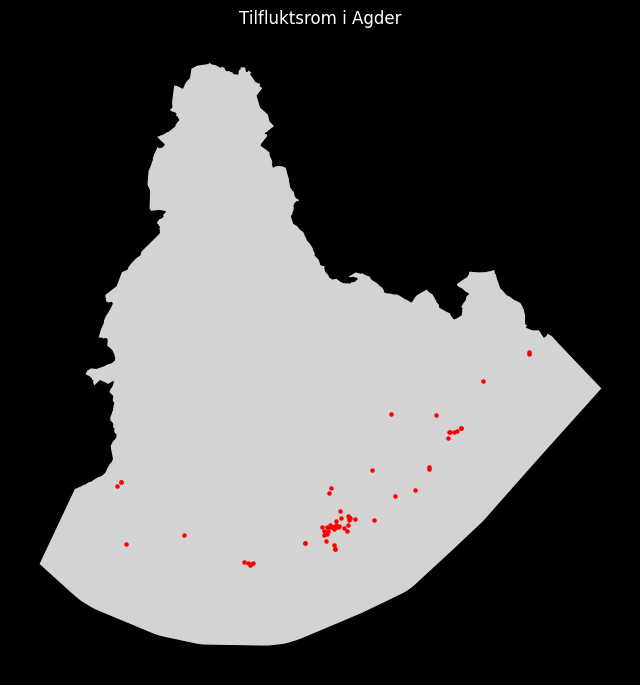

In [23]:
fig, ax = plt.subplots(figsize=(8, 10))

gdf_agder.plot(ax=ax, color="lightgrey", edgecolor="black")
gdf_shelters.plot(ax=ax, color="red", markersize=5)

ax.set_title("Tilfluktsrom i Agder")
ax.set_axis_off()

plt.show()

Visualiseringen viser at tilfluktsrommene er fordelt ulikt i Agder, og danner et første grunnlag for å undersøke om denne fordelingen samsvarer med hvor befolkningen bor.